## Model Evaluation

This notebook evaluates the performance of the trained spam classification model using a range of metrics and diagnostic techniques. While accuracy provides a useful overview, it does not fully capture the types of errors a model makes or how confidently it separates spam from ham emails. A more comprehensive evaluation is therefore required.

The analysis includes:

* **Confusion Matrix** - identifies which emails are being misclassified.
* **Precision, Recall, and F1 Score** - measures performance for each class.
* **ROC Curve and AUC** - evaluates the model's ability to distinguish between classes across different thresholds.
* **Precision-Recall Curve** - provides additional insight into classification trade-offs.
* **Threshold Analysis** - examines how performance changes when the decision threshold is adjusted.
* **Error Analysis** - investigates misclassified emails to better understand model weaknesses and limitations.


In [ ]:
# Mounting Google Drive to access the dataset and model. Alternatively, you may upload the dataset and model directly from your local storage.

from google.colab import drive
drive.mount('/content/drive')

# Change this according to where your dataset is stored.
dataset_path ="/content/drive/MyDrive/Spam-Ham Dataset/cleaned.csv"

# Change this according to where your model is stored.
model_path = "/content/drive/MyDrive/Spam-Ham Dataset/naive_bayes_model.pkl"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import all required packages for the model evaluation.

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

import warnings
warnings.filterwarnings("ignore")

# Create assets folder for model evaluation outputs
EVAL_PLOT_DIR = "/content/assets/evaluation_models"
os.makedirs(EVAL_PLOT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 150

print("Evaluation folder created:", EVAL_PLOT_DIR)

Evaluation folder created: /content/assets/evaluation_models


In [ ]:
# Load the model and the dataset

# Paths
dataset_path = "/content/drive/MyDrive/Spam-Ham Dataset/cleaned.csv"
model_path = "/content/drive/MyDrive/Spam-Ham Dataset/naive_bayes_model.pkl"

# Load the model
model = joblib.load(model_path)

# Recreate exact same split as training
df = pd.read_csv(dataset_path)

X = df["text"]
y = df["label_enc"]

_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Test size: {len(X_test)}")
print(f"Spam in test: {y_test.sum()}")
print(f"Ham in test: {(y_test == 0).sum()}")

Test size: 38319
Spam in test: 18197
Ham in test: 20122


## Confusion Matrix

A confusion matrix provides a detailed breakdown of a classifier's predictions by comparing predicted labels against the true labels.

* **True Positive (TP):** The model predicts spam and the email is actually spam.
* **True Negative (TN):** The model predicts ham and the email is actually ham.
* **False Positive (FP):** The model predicts spam when the email is actually ham.
* **False Negative (FN):** The model predicts ham when the email is actually spam.

For spam detection, false negatives are generally considered the more costly error because unwanted spam reaches the user's inbox. False positives are also undesirable, as legitimate emails may be incorrectly sent to the junk folder, but they are often easier for users to recover and review.


True Negatives  (Ham → Ham)   : 19627
False Positives (Ham → Spam)  : 495  ← real emails flagged as spam
False Negatives (Spam → Ham)  : 1334  ← spam that slipped through
True Positives  (Spam → Spam) : 16863


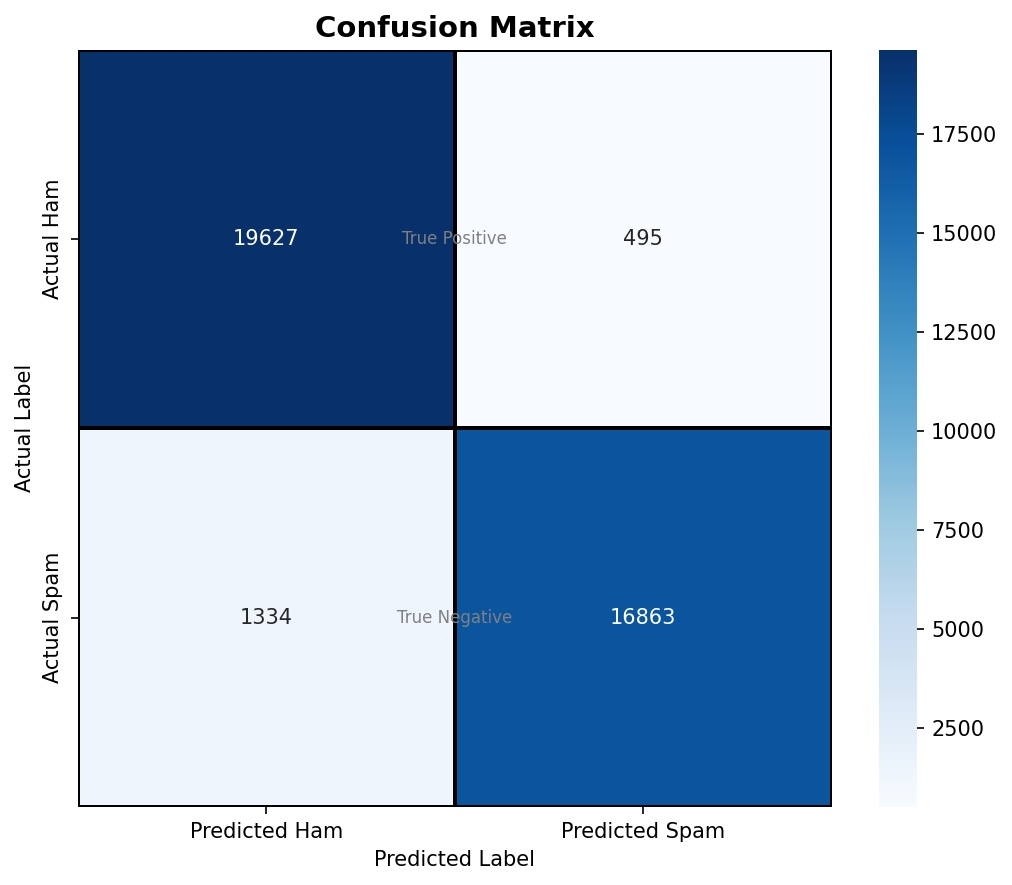

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (Ham → Ham)   : {tn}")
print(f"False Positives (Ham → Spam)  : {fp}  ← real emails flagged as spam")
print(f"False Negatives (Spam → Ham)  : {fn}  ← spam that slipped through")
print(f"True Positives  (Spam → Spam) : {tp}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Ham", "Predicted Spam"],
            yticklabels=["Actual Ham", "Actual Spam"],
            linewidths=1, linecolor="black", ax=ax)

# add FP/FN labels
ax.text(0.5, 0.25, "True Negative", ha="center", va="center",
        transform=ax.transAxes, fontsize=8, color="gray")
ax.text(0.5, 0.75, "True Positive", ha="center", va="center",
        transform=ax.transAxes, fontsize=8, color="gray")

ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PLOT_DIR, "confusion_matrix.png"))
plt.show()

## Precision, Recall, and F1 Score

Precision measures how many emails predicted as spam were actually spam. A high precision score indicates that few legitimate emails are incorrectly placed in the junk folder.

Recall measures how many of the actual spam emails were successfully identified by the model. A high recall score means that fewer spam emails are missed and allowed into the inbox.

The F1 score combines precision and recall into a single metric by calculating their harmonic mean. It provides a balanced measure of performance and penalises models that perform well on one metric but poorly on the other.

In the context of spam filtering, recall is often considered particularly important because allowing spam emails into a user's inbox is generally more costly than occasionally misclassifying a legitimate email as spam.


In [ ]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print(f"Precision : {precision:.4f}  — {precision*100:.1f}% of predicted spam is real spam")
print(f"Recall    : {recall:.4f}  — {recall*100:.1f}% of actual spam was caught")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nFull Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Precision : 0.9715  — 97.1% of predicted spam is real spam
Recall    : 0.9267  — 92.7% of actual spam was caught
F1 Score  : 0.9486
ROC-AUC   : 0.9935

Full Report:
              precision    recall  f1-score   support

         Ham       0.94      0.98      0.96     20122
        Spam       0.97      0.93      0.95     18197

    accuracy                           0.95     38319
   macro avg       0.95      0.95      0.95     38319
weighted avg       0.95      0.95      0.95     38319



## ROC Curve and AUC

The ROC (Receiver Operating Characteristic) curve visualises model performance by plotting the **True Positive Rate** against the **False Positive Rate** across all possible classification thresholds.

By default, the classifier uses a threshold of **0.5**, where emails with predicted probabilities above the threshold are classified as spam. The ROC curve shows how performance changes as this threshold is adjusted.

The **Area Under the Curve (AUC)** provides a threshold-independent measure of model quality. An AUC of **1.0** represents perfect classification, while an AUC of **0.5** indicates performance equivalent to random guessing. An AUC close to **0.99** suggests that the model is highly effective at distinguishing between spam and ham emails.

The dotted diagonal line on the ROC plot represents the performance of a random classifier. A stronger model produces a curve that lies well above this baseline and approaches the upper-left corner of the graph.


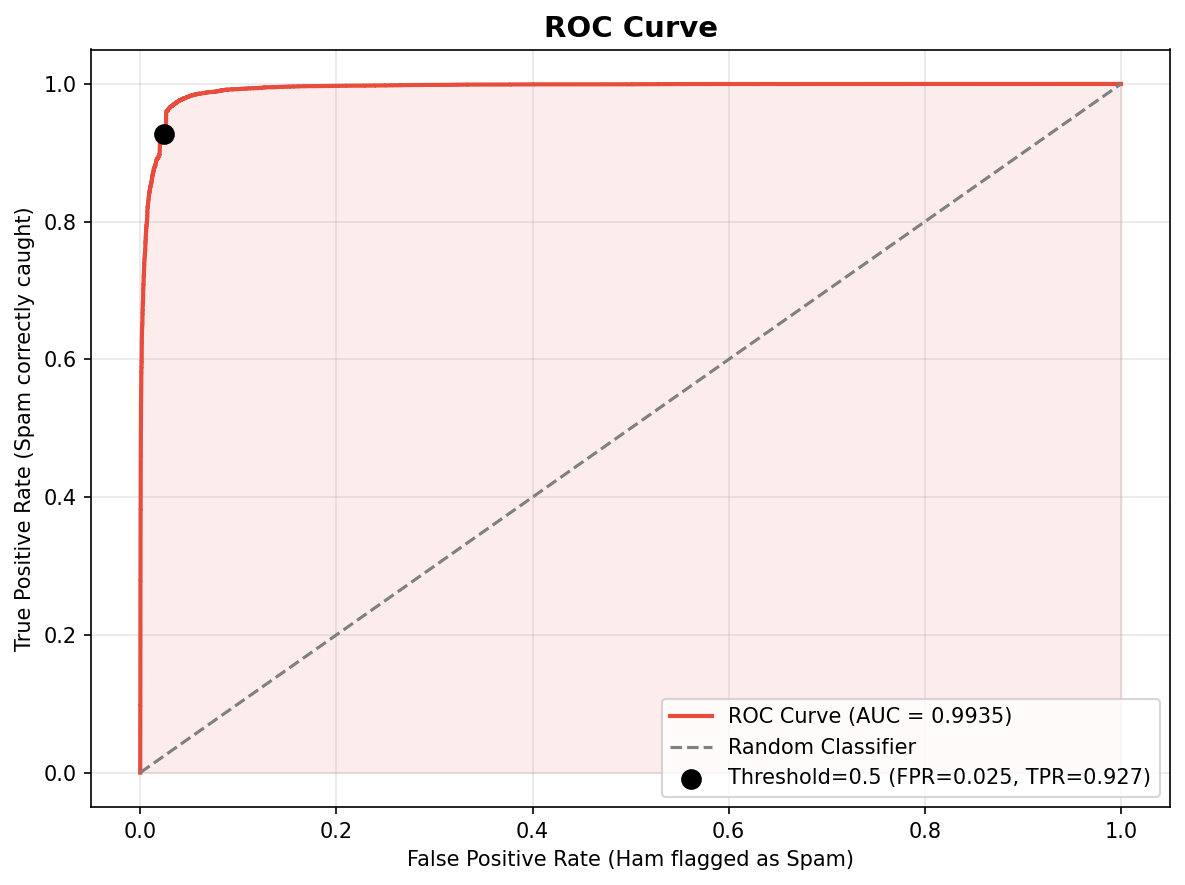

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#e74c3c", lw=2,
        label=f"ROC Curve (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")

# mark the default threshold point
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color="black", zorder=5, s=80,
           label=f"Threshold=0.5 (FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f})")

ax.set_xlabel("False Positive Rate (Ham flagged as Spam)")
ax.set_ylabel("True Positive Rate (Spam correctly caught)")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PLOT_DIR, "roc_curve.png"))
plt.show()

## Precision-Recall Curve

The Precision-Recall curve provides a focused view of the trade-off between **recall** and **precision**. It illustrates how model performance changes as the classification threshold is adjusted.

Increasing recall allows the model to catch more spam emails, while increasing precision reduces the number of legitimate emails incorrectly flagged as spam. The curve helps visualise the balance between these competing objectives.

A perfect classifier achieves an **AUC-PR score of 1.0**, while the baseline corresponds to the proportion of positive samples in the dataset, which is approximately **0.47** in this case. Because it focuses directly on precision and recall, the Precision-Recall curve often provides a more informative assessment of spam detection performance than the ROC curve.


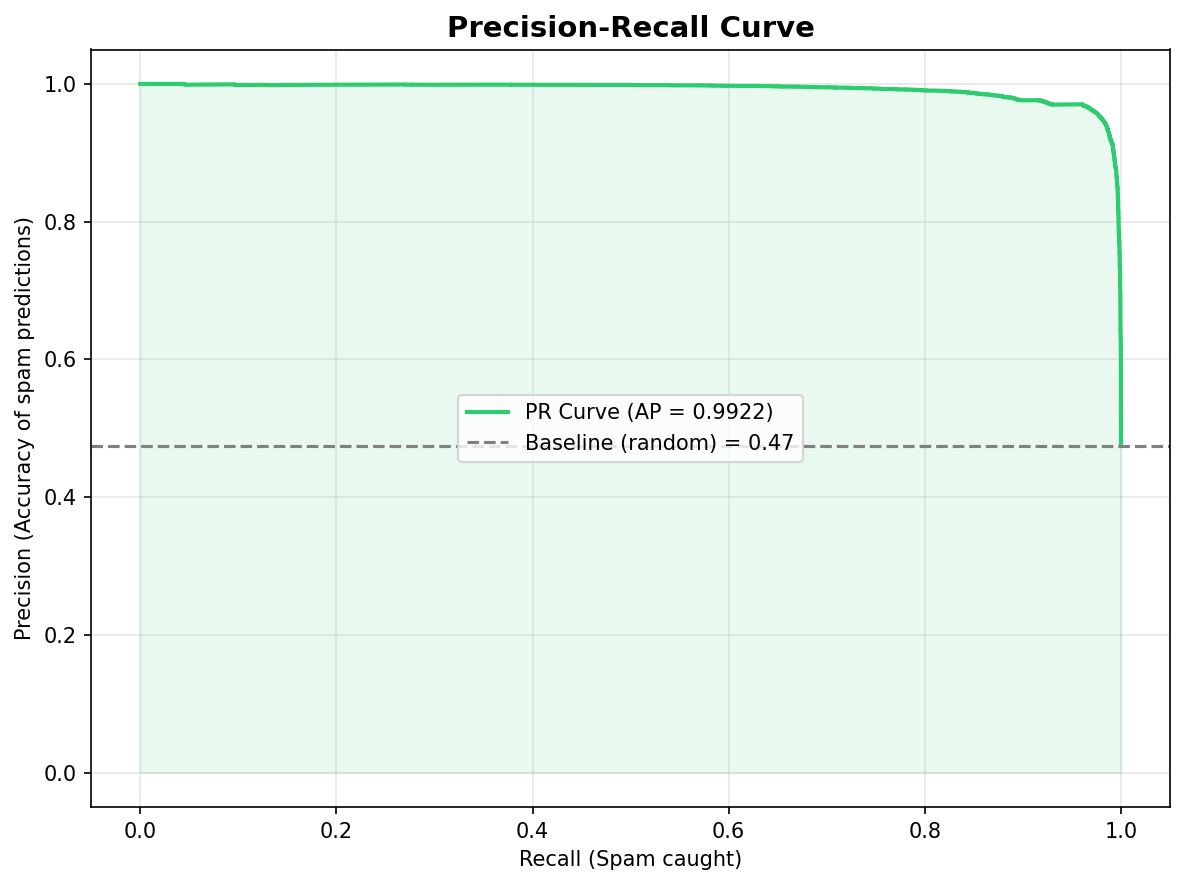

In [ ]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color="#2ecc71", lw=2,
        label=f"PR Curve (AP = {ap_score:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           label=f"Baseline (random) = {y_test.mean():.2f}")
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color="#2ecc71")

ax.set_xlabel("Recall (Spam caught)")
ax.set_ylabel("Precision (Accuracy of spam predictions)")
ax.set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PLOT_DIR, "pr_curve.png"))
plt.show()

## Threshold Analysis

The default classification threshold is **0.5**, meaning emails with predicted spam probabilities above this value are classified as spam. Adjusting the threshold changes the balance between catching spam and avoiding false alarms.

Lowering the threshold increases recall, allowing the model to identify more spam emails, but it may also increase the number of legitimate emails incorrectly marked as spam. Raising the threshold has the opposite effect, reducing false positives while allowing more spam emails to pass through.

The choice of threshold ultimately depends on the desired trade-off. A stricter spam filter prioritises catching as much spam as possible, whereas a more lenient filter focuses on minimising the risk of legitimate emails being sent to the junk folder.


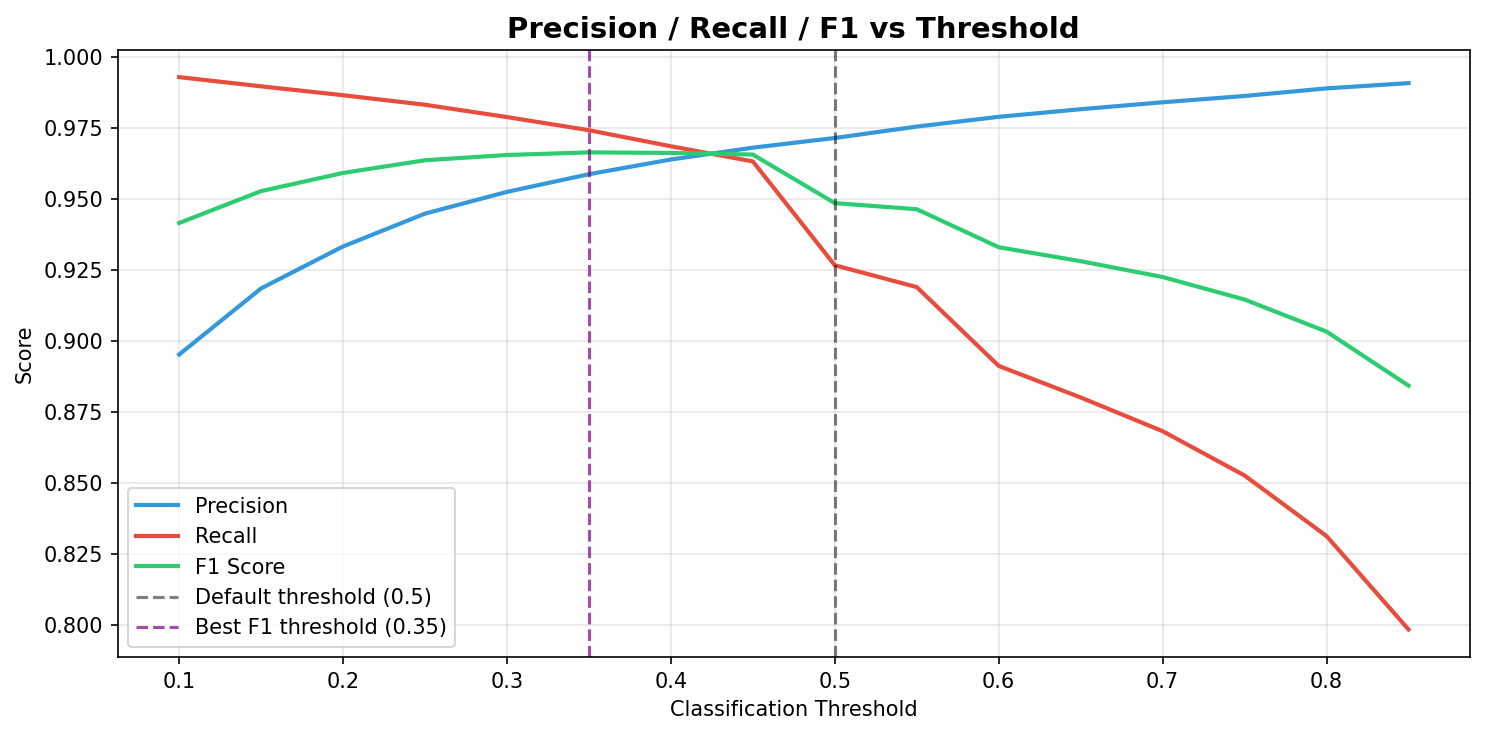

Best F1 at threshold: 0.35 → F1 = 0.9664


In [ ]:
threshold_vals = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1_scores = [], [], []

for t in threshold_vals:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_vals, precisions, label="Precision", color="#3498db", lw=2)
ax.plot(threshold_vals, recalls,    label="Recall",    color="#e74c3c", lw=2)
ax.plot(threshold_vals, f1_scores,  label="F1 Score",  color="#2ecc71", lw=2)
ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, label="Default threshold (0.5)")

best_t = threshold_vals[np.argmax(f1_scores)]
ax.axvline(x=best_t, color="purple", linestyle="--", alpha=0.7,
           label=f"Best F1 threshold ({best_t:.2f})")

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PLOT_DIR, "threshold_analysis.png"))
plt.show()

print(f"Best F1 at threshold: {best_t:.2f} → F1 = {max(f1_scores):.4f}")

## Error Analysis

Evaluation metrics provide a useful summary of model performance, but examining misclassified emails often reveals the underlying reasons for model errors. Error analysis helps identify patterns that may not be visible through aggregate metrics alone.

Two types of errors are investigated:

* **False Positives:** Legitimate ham emails that were incorrectly classified as spam.
* **False Negatives:** Spam emails that were incorrectly classified as ham.

By reviewing these examples, we can better understand the model's weaknesses and identify opportunities for improving feature engineering, preprocessing, or classification thresholds.


In [ ]:
# Build results of dataframe

results_df = pd.DataFrame({
    "text"      : X_test.values,
    "actual"    : y_test.values,
    "predicted" : y_pred,
    "spam_prob" : y_prob
})

false_positives = results_df[(results_df["actual"] == 0) &
                              (results_df["predicted"] == 1)].sort_values(
                              "spam_prob", ascending=False)

false_negatives = results_df[(results_df["actual"] == 1) &
                              (results_df["predicted"] == 0)].sort_values(
                              "spam_prob", ascending=True)

print(f"Total False Positives (Ham → Spam) : {len(false_positives)}")
print(f"Total False Negatives (Spam → Ham) : {len(false_negatives)}")

Total False Positives (Ham → Spam) : 495
Total False Negatives (Spam → Ham) : 1334


In [ ]:
print("=" * 70)
print("FALSE NEGATIVES — Spam emails that slipped through as Ham")
print("=" * 70)
for i, row in false_negatives.head(5).iterrows():
    print(f"\nSpam Probability : {row['spam_prob']:.4f}")
    print(f"Email Preview    : {row['text'][:300]}")
    print("-" * 70)

FALSE NEGATIVES — Spam emails that slipped through as Ham

Spam Probability : 0.0006
Email Preview    : ferc escapenumber escapenumber changing wholesale power market june escapenumber escapenumber escapenumber washington july escapenumber escapenumber escapenumber houston click here download complete conference brochure includes special depth analysis ferc april escapenumberth april escapenumberth or
----------------------------------------------------------------------

Spam Probability : 0.0010
Email Preview    : understanding fercs role impact rapidly changing wholesale power market across ferc escapenumber escapenumber changing wholesale power market march escapenumber escapenumber escapenumber chicago click download complete conference brochure click register line popular program dated include depth minut
----------------------------------------------------------------------

Spam Probability : 0.0010
Email Preview    : energy info source transmission report escapenumber page esc

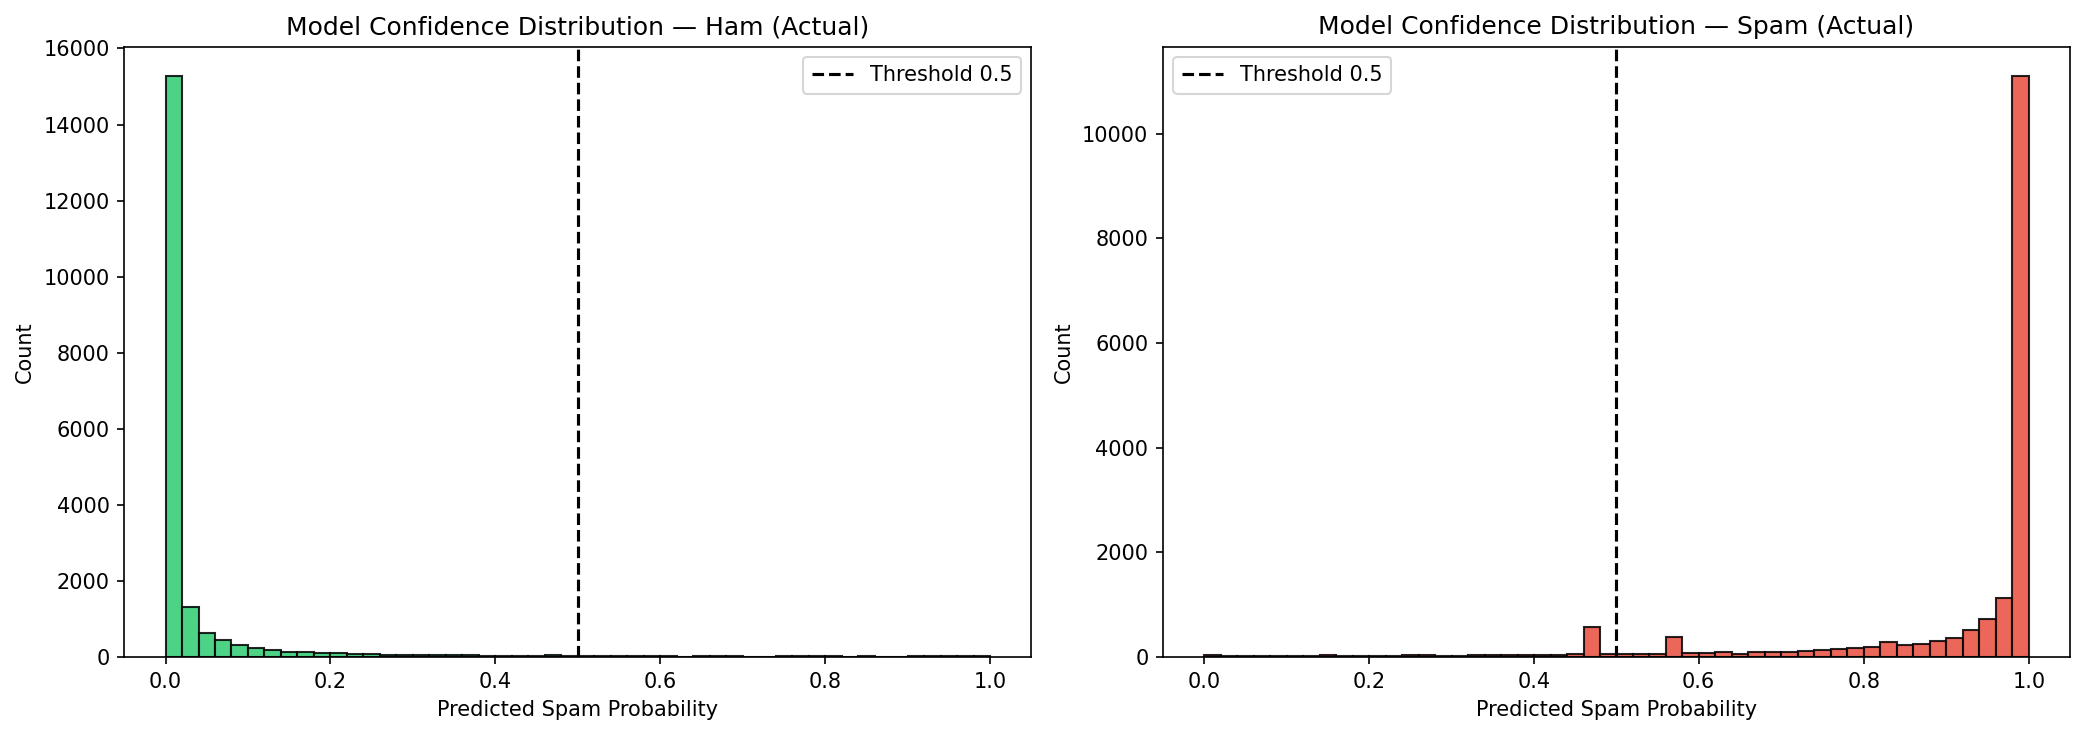

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label_val, label_name, color) in zip(
    axes,
    [(0, "Ham (Actual)", "#2ecc71"), (1, "Spam (Actual)", "#e74c3c")]
):
    probs = results_df[results_df["actual"] == label_val]["spam_prob"]
    ax.hist(probs, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax.axvline(x=0.5, color="black", linestyle="--", label="Threshold 0.5")
    ax.set_title(f"Model Confidence Distribution — {label_name}")
    ax.set_xlabel("Predicted Spam Probability")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PLOT_DIR, "confidence_distribution.png"))
plt.show()

## Evaluation Summary and Conclusions

The model demonstrates strong performance on the spam classification task, achieving an **accuracy of 95.23%**, an **F1 score of 0.9486**, a **ROC-AUC of 0.9935**, and a **PR-AUC of 0.9922** on a test set of **38,319 emails**. These results indicate excellent separation between spam and ham emails and show that the classifier performs consistently across a range of decision thresholds.

The model achieves particularly high precision for spam detection, meaning that emails classified as spam are usually correct. Ham recall is also very high, indicating that only a small number of legitimate emails are incorrectly flagged as spam. Analysis of prediction probabilities further confirms strong class separation, with ham emails typically assigned probabilities close to 0 and spam emails assigned probabilities close to 1.

Despite these strong results, some limitations remain. A total of **1,332 spam emails** were misclassified as ham, resulting in a spam recall of **0.9268**. Many of these missed spam emails resemble formal business communication and therefore lack the obvious characteristics typically associated with spam. Additionally, **495 legitimate emails** were incorrectly classified as spam, often because they contained keywords, URLs, or numerical patterns commonly found in spam messages.

These errors highlight a key limitation of the Multinomial Naive Bayes algorithm. The model treats words as independent features and does not consider context or word order. As a result, legitimate emails containing spam-related keywords may be incorrectly flagged, while well-written spam emails that mimic professional communication can sometimes evade detection.

Overall, the classifier provides a highly effective baseline solution for spam detection. However, further improvements may be possible through additional feature engineering, threshold optimisation, enhanced preprocessing techniques, and experimentation with alternative models such as Logistic Regression, Support Vector Machines, and deep learning approaches including LSTM, BiLSTM, Transformer, and BERT-based architectures.

The results demonstrate that a relatively simple TF-IDF and Naive Bayes pipeline can achieve excellent performance, while also highlighting opportunities for future research and refinement.
